In [1]:
import sys
print(sys.executable)

import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

print("Kernel funktioniert.")

c:\Users\AnnKa\AppData\Local\spyder-6\envs\spyder-runtime\python.exe


c:\Users\AnnKa\AppData\Local\spyder-6\envs\spyder-runtime\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Kernel funktioniert.


In [ ]:
import os
from pathlib import Path

print("Current working directory:", os.getcwd())
print("Files in this folder:", [p.name for p in Path.cwd().iterdir()])

Exists: True
Current working directory: C:\Users\AnnKa\Downloads\LCC_AWE_PEMWE_script\PEMWE_version


C:\Users\AnnKa\AppData\Local\Temp\ipykernel_36224\3348614076.py:67: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  capex_df.fillna('', inplace=True)
C:\Users\AnnKa\AppData\Local\Temp\ipykernel_36224\3348614076.py:139: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_eol.fillna('', inplace=True)


              Material and Component               Amount Unit  \
0                    Stainless steel              625.000   kg   
1                             Copper               68.000   kg   
2                           Titanium            3,987.000   kg   
3                           Platinum                0.670   kg   
4                            Iridium                9.860   kg   
5                 Carbon Paper / GDL              329.000  pcs   
6                        Nafion N117               88.540   m2   
7                    FKM gasket/seal                1.000  pcs   
8       Stack Cooling Heat Exchanger                1.000  pcs   
9                          Condenser                1.000  pcs   
10              Gas Water Separators                2.000  pcs   
11                        Dry Cooler                1.000  pcs   
12                       Power Cable               50.000    m   
13                        Data Cable            2,000.000    m   
14        

08:36:13 - cmdstanpy - INFO - Chain [1] start processing
08:36:13 - cmdstanpy - INFO - Chain [1] done processing


Predicting no_tax for 20 Years...


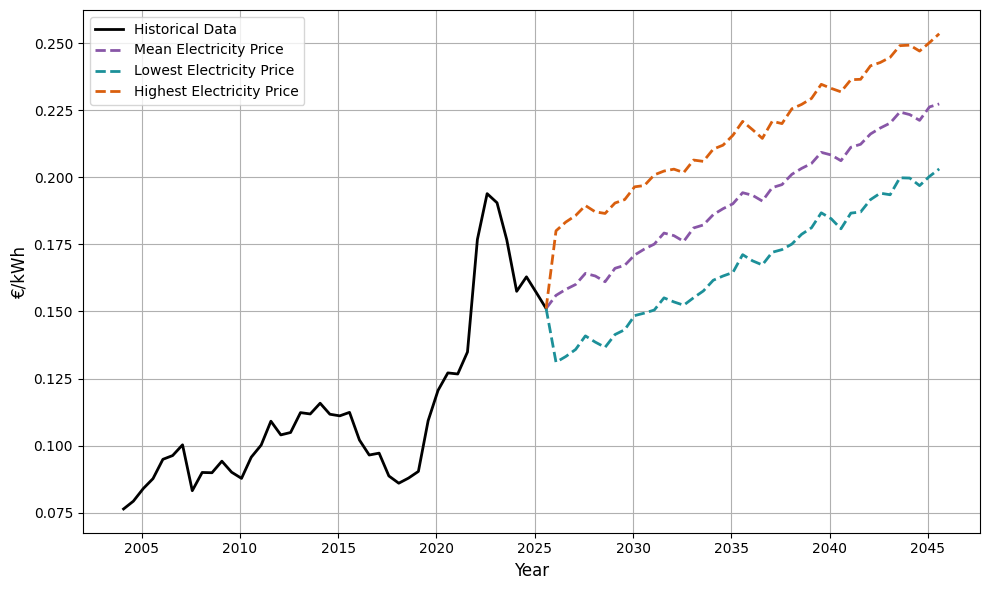

08:36:15 - cmdstanpy - INFO - Chain [1] start processing
08:36:15 - cmdstanpy - INFO - Chain [1] done processing


Predicting no_tax for 3 Years...


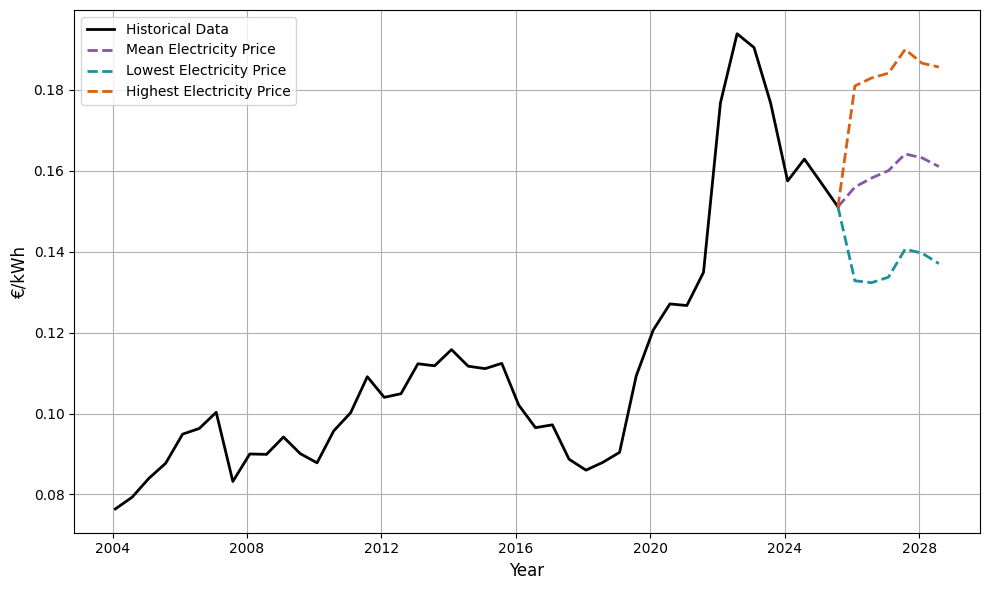

08:36:17 - cmdstanpy - INFO - Chain [1] start processing
08:36:17 - cmdstanpy - INFO - Chain [1] done processing


Predicting no_tax for 20 Years...


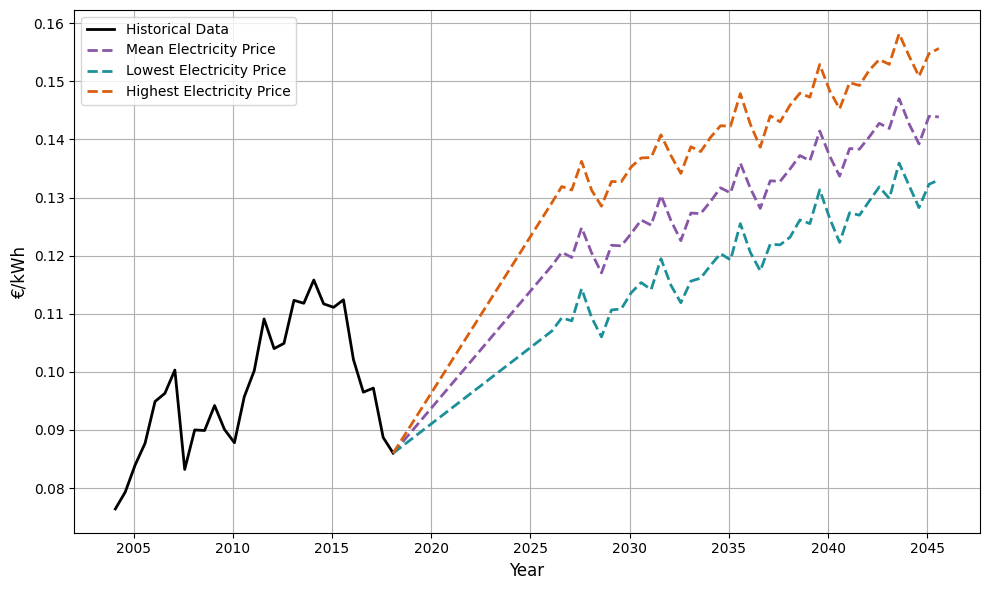

C:\Users\AnnKa\AppData\Local\Temp\ipykernel_36224\3348614076.py:347: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prophet_elc_rest.drop(list(range(6)), axis=0, inplace=True)  # 🔴 GEÄNDERT: drop first 3 years (6 half-year points)


     S2_elc_price_lower   S2_elc_price_upper    S2_elc_price_mean       DATE
6                 0.111                0.133                0.122 2029-01-31
7                 0.111                0.133                0.122 2029-07-31
8                 0.114                0.135                0.124 2030-01-31
9                 0.115                0.137                0.126 2030-07-31
10                0.114                0.137                0.125 2031-01-31
11                0.119                0.141                0.130 2031-07-31
12                0.115                0.137                0.126 2032-01-31
13                0.112                0.134                0.123 2032-07-31
14                0.116                0.139                0.127 2033-01-31
15                0.116                0.138                0.127 2033-07-31
16                0.118                0.140                0.129 2034-01-31
17                0.120                0.142                0.132 2034-07-31

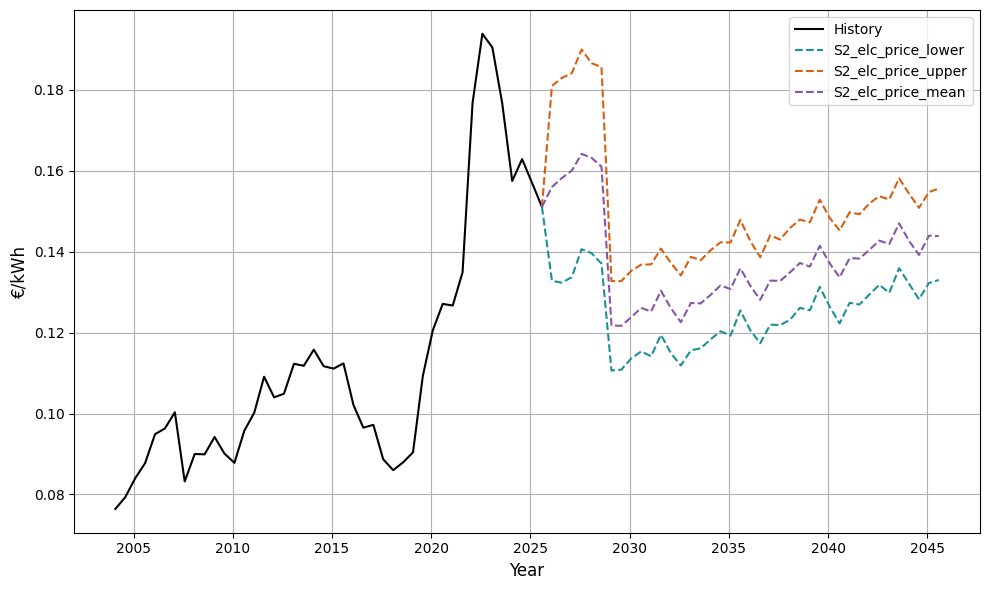

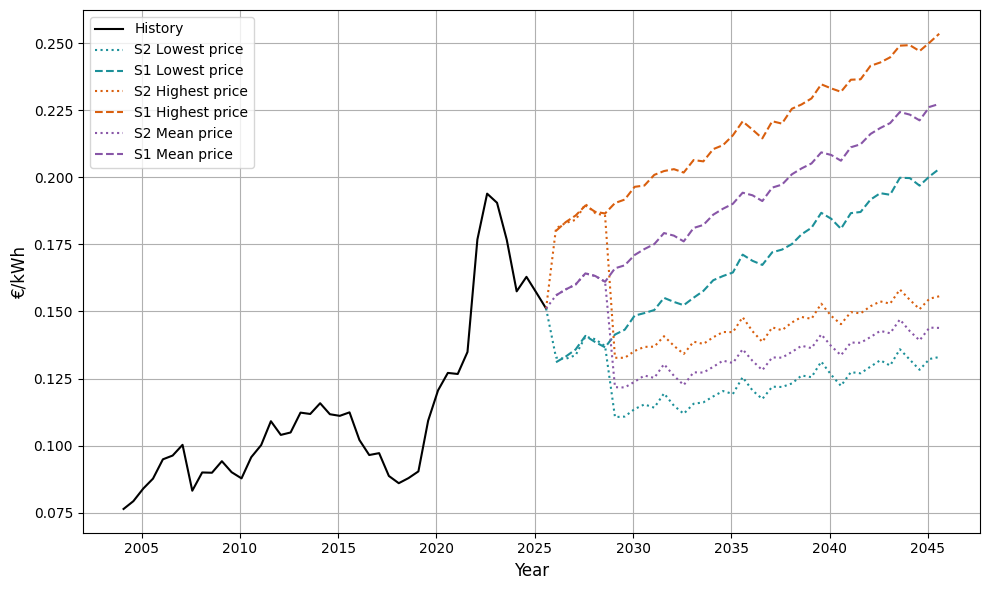

08:36:20 - cmdstanpy - INFO - Chain [1] start processing
08:36:20 - cmdstanpy - INFO - Chain [1] done processing


Predicting WF for 20 Years...


08:36:21 - cmdstanpy - INFO - Chain [1] start processing
08:36:21 - cmdstanpy - INFO - Chain [1] done processing


Predicting WWF for 20 Years...


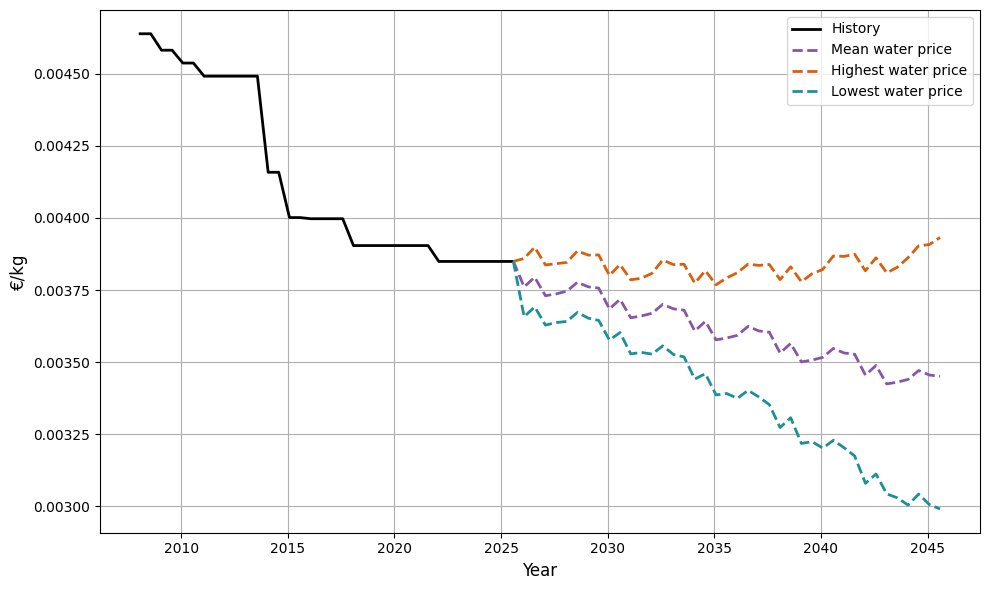

         H2 Production H2 Unit         Needed Water Water Price Unit  \
0          444,911.510      kg                9.300             €/kg   
1          444,911.510      kg                9.300             €/kg   
2          444,911.510      kg                9.300             €/kg   
3          444,911.510      kg                9.300             €/kg   
4          444,911.510      kg                9.300             €/kg   

    Needed Electricity Electricity Price Unit      wat_price_lower  \
0               50.000                  €/kWh                0.004   
1               50.000                  €/kWh                0.004   
2               50.000                  €/kWh                0.004   
3               50.000                  €/kWh                0.004   
4               50.000                  €/kWh                0.004   

       wat_price_upper       wat_price_mean   S1_elc_price_lower  ...  \
0                0.004                0.004                0.131  ...   


In [3]:
#%%
# Original-style LCC tool with current technology-specific numbers
# Run cell-by-cell in Spyder, or run the full file with F5 after installing the original dependencies.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from functools import reduce


# helper to make forecast plots start at the last historical point,
# so there is no visual gap between history and prediction.
def connect_forecast_to_history(history_df, forecast_df, forecast_cols, history_col="History"):
    forecast_plot = forecast_df.copy()
    last_date = history_df["DATE"].iloc[-1]
    last_value = history_df[history_col].iloc[-1]
    first_date = forecast_plot["DATE"].iloc[0]
    if pd.to_datetime(first_date) != pd.to_datetime(last_date):
        start_row = {"DATE": last_date}
        for col in forecast_cols:
            start_row[col] = last_value
        forecast_plot = pd.concat([pd.DataFrame([start_row]), forecast_plot], ignore_index=True)
    return forecast_plot


from utils import prophet_fit_predict_elc, prophet_fit_predict_water, \
                        prophet_fit_predict_3_years_after_war, prophet_fit_predict_elc_rest, \
                        invest_cost, deconstruction_cost, end_of_life_cost, \
                        operation_cost, life_cycle_cost_of_h2, levelized_cost_of_h2

from data import data_elc, water_data, data_nw_elc

pd.options.display.float_format = '{:20,.3f}'.format

#%%
# CAPEX - material/component cost for 5 MW PEMWE with current prices

technology = 'PEMWE'

capex_material = ['Stainless steel', 'Copper', 'Titanium', 'Platinum', 'Iridium', 'Carbon Paper / GDL', 'Nafion N117', 'FKM gasket/seal', 'Stack Cooling Heat Exchanger', 'Condenser', 'Gas Water Separators', 'Dry Cooler', 'Power Cable', 'Data Cable', 'Pumps', 'Rectifier / power electronics', 'Control Unit', 'Housing', 'Foundation']
capex_amount = [625.0, 68.0, 3987.0, 0.67, 9.86, 329.0, 88.54, 1.0, 1.0, 1.0, 2.0, 1.0, 50.0, 2000.0, 6.0, 1.0, 1.0, 2.0, 4.5]
capex_unit = ['kg', 'kg', 'kg', 'kg', 'kg', 'pcs', 'm2', 'pcs', 'pcs', 'pcs', 'pcs', 'pcs', 'm', 'm', 'pcs', 'pcs', 'pcs', 'pcs', 'm3']
capex_price = [2.4394400000000003, 11.683088235294118, 6.124201153749686, 55039.55223880597, 206467.59939148076, 122.03258358662616, 3966.666704314434, 236.97, 48000.0, 42000.0, 2480.77, 34000.0, 92.0, 0.78, 9300.0, 320699.0, 6600.0, 4950.0, 181.0]
capex_single_price_unit = ['€/kg', '€/kg', '€/kg', '€/kg', '€/kg', '€/unit', '€/m2', '€/unit', '€/unit', '€/unit', '€/unit', '€/unit', '€/m', '€/m', '€/unit', '€/unit', '€/unit', '€/unit', '€/m3']
capex_price_unit = ['€'] * len(capex_material)

# Use pandas to organise the data as in the original script
capex_df = pd.DataFrame({
    'Material and Component': capex_material,
    'Amount': capex_amount,
    'Unit': capex_unit,
    'Single Price': capex_price,
    'Single Price Unit': capex_single_price_unit,
    'Price Unit': capex_price_unit,
})

# Calculate price based on amount and single price
capex_df.insert(5, 'Price', [a*b for a, b in zip(capex_df['Amount'], capex_df['Single Price'])])

# Calculate total price of every material/component. pandas.append was replaced by pd.concat.
total_row = pd.DataFrame([{'Material and Component': 'Total', 'Price': capex_df['Price'].sum(), 'Price Unit': '€'}])
capex_df = pd.concat([capex_df, total_row], ignore_index=True)
capex_df.index = [*range(len(capex_df)-1), 'Total']
capex_df.fillna('', inplace=True)

# Keep df name from the original notebook for compatibility with older following cells
df = capex_df

print(capex_df)

#%%
# CAPEX result (one figure)

# Extract total cost/price from the defined dataframe
material_cost = capex_df['Price'].loc['Total']

# Feed needed data in, following the original script
kwargs={
        'inflation_rate' : 0.01,
        'equity' : 0.25,
        'eq_rate_return' : 0.07,
        'debt' : 0.75,
        'db_intrst_rate' : 0.045,
        'material_full' : material_cost,
        'per_m' : 0.208
        }

# Sort Labour and Investment cost out 
inv_cost = invest_cost(material=material_cost, ictg=0, **kwargs)
print(f"Investment Cost {inv_cost:.2f}")

#%%
# OPEX S1 and S2 - End of Life (EoL) cost - Salvage value (SV)
# Current-price PEMWE version. Structure follows the original script.

eol_material = ['Stainless steel', 'Copper', 'Titanium', 'Platinum', 'Iridium', 'Carbon Paper / GDL', 'Nafion N117', 'FKM gasket/seal', 'Stack Cooling Heat Exchanger', 'Condenser', 'Gas Water Separators', 'Dry Cooler', 'Power Cable', 'Data Cable', 'Pumps', 'Rectifier / power electronics', 'Control Unit', 'Housing', 'Foundation']
eol_amount = [625.0, 68.0, 3987.0, 0.67, 9.86, 329.0, 88.54, 1.0, 1.0, 1.0, 2.0, 1.0, 50.0, 2000.0, 6.0, 1.0, 1.0, 2.0, 4.5]
eol_material_unit = ['kg', 'kg', 'kg', 'kg', 'kg', 'pcs', 'm2', 'pcs', 'pcs', 'pcs', 'pcs', 'pcs', 'm', 'm', 'pcs', 'pcs', 'pcs', 'pcs', 'm3']

# Recycling/disposal assumptions are kept in the same style as the original script.
# Metals use scrap/recycling proxies; membranes/polymers/special components are treated conservatively as disposal/no salvage.
recycling_rate = [0.88, 0.7, 0.4, 0.76, 0.4, 0.0, 0.0, 0.0, 0.72, 0.72, 0.72, 0.72, 0.7, 0.7, 0.72, 0.72, 0.72, 0.88, 0.88]
disposal_percent = [0.12, 0.3, 0.6, 0.24, 0.6, 1.0, 1.0, 1.0, 0.28, 0.28, 0.28, 0.28, 0.3, 0.3, 0.28, 0.28, 0.28, 0.12, 0.12]
selling_price = [0.23, 7.13, 0.0, 16780.0, 0.0, 0.0, 0.0, 0.0, 0.27, 0.27, 0.27, 0.27, 1.95, 1.95, 0.27, 0.27, 0.27, 0.23, 0.23]
transport_cost = [0.23, 0.23, 0.23, 0.23, 0.23, 0.23, 0.23, 0.23, 0.23, 0.23, 0.23, 0.23, 0.23, 0.23, 0.23, 0.23, 0.23, 0.23, 0.23]

recycle_unit = ['€/kg'] * len(eol_material)
transport_cost_unit = ['€/kg'] * len(eol_material)

df_eol = pd.DataFrame({
    'Material': eol_material,
    'Amount': eol_amount,
    'Amount unit': eol_material_unit,
    'Recycling rate': recycling_rate,
    'Selling price': selling_price,
    'Price unit': recycle_unit,
    'Disposal percentage': disposal_percent,
    'Disposal unit': eol_material_unit,
    'Transport single cost': transport_cost,
    'Transport cost unit': transport_cost_unit
})

df_eol.insert(4, 'Recycling amount', [a*b for a, b in zip(df_eol['Amount'], df_eol['Recycling rate'])])
df_eol.insert(8, 'Disposal amount', [a*b for a, b in zip(df_eol['Amount'], df_eol['Disposal percentage'])])
df_eol.insert(12, 'Transport cost', [a*b for a, b in zip(df_eol['Amount'], df_eol['Transport single cost'])])
df_eol.insert(13, 'Salvage value', [a*b for a, b in zip(df_eol['Recycling amount'], df_eol['Selling price'])])

total_row = pd.DataFrame([{
    'Material': 'Total',
    'Disposal amount': df_eol['Disposal amount'].sum(),
    'Transport cost': df_eol['Transport cost'].sum(),
    'Salvage value': df_eol['Salvage value'].sum()
}])
df_eol = pd.concat([df_eol, total_row], ignore_index=True)
df_eol.index = [*range(len(df_eol)-1), 'Total']
df_eol.fillna('', inplace=True)

transport_cost_disposal = df_eol['Transport cost'].loc['Total']
salvage_value = df_eol['Salvage value'].loc['Total']

print(df_eol)
print(f"Transport/disposal cost: {transport_cost_disposal:.2f} EUR")
print(f"Salvage value: {salvage_value:.2f} EUR")

#%%
# OPEX S1 and S2 - Deconstruction cost

decon_cost = deconstruction_cost(construction_cost=material_cost, percentage_of_cc=0.06)
print(f"Deconstruction cost {decon_cost:.2f}")

#%%
# OPEX S1 and S2 - EoL cost

kwargs={
        'equity' : 0.25,
        'eq_rate_return': 0.07,
        'debt': 0.75,
        'db_intrst_rate': 0.045,
        'construction_cost' : material_cost,
        'percentage_of_cc' : 0.06,
        'inflation_rate' : 0.01
        }

eol_cost, wacc_r = end_of_life_cost(transport_cost_disposal=transport_cost_disposal,
                                    salvage_value=salvage_value,
                                    **kwargs)
print(f"End of Life Cost {eol_cost:.2f}")
print(f"WACC real {wacc_r:.4f}")

#%%
# Prophet - electricity (elc.) cost prediction in scenario 1 (S1)

# Insert historical data for elc. cost
df_elc = pd.DataFrame(data=data_elc)

# Run Prophet for elc. cost prediction (here only incl. "Beschaffung, Netzentgelt, Vertrieb"(BNV) + "Konzessionsabgabe"(KA))
# Use Pandas' iloc function to extract the yhat_lower(2), yhat_upper(3) and yhat(15) (mean) from the prophet result dataframe
prophet_NT_hat = prophet_fit_predict_elc(odf=df_elc, var="no_tax", years=20, plot=False).iloc[: , [2, 3, 15]]

# - if followed element of elc. cost needed to be considered, then... - 
# EEG-Umlage:                     prophet_EEGU_hat = prophet_fit_predict(odf=df_elc, var="EEGU", years=20, plot=False).iloc[: , [2, 3, 15]]
# KWKG-Umlage:                    prophet_KWKG_hat = prophet_fit_predict(odf=df_elc, var="KWKG", years=20, plot=False).iloc[: , [2, 3, 15]]
# §19 StromNEV-Umlage:            prophet_NU_hat = prophet_fit_predict(odf=df_elc, var="19U", years=20, plot=False).iloc[: , [2, 3, 15]]
# Offshore-Netzumlage:            prophet_ONU_hat = prophet_fit_predict(odf=df_elc, var="ONU", years=20, plot=False).iloc[: , [2, 3, 15]]
# Umlage für abschaltbare Lasten: prophet_UAL_hat = prophet_fit_predict(odf=df_elc, var="UAL", years=20, plot=False).iloc[: , [2, 3, 15]]
# Stromsteuer:                    prophet_SST_hat = prophet_fit_predict(odf=df_elc, var="SST", years=20, plot=False).iloc[: , [2, 3, 15]]


# Results of elc. cost prediction (plot + table)
# Apply an add reduce lambda function to the values of each row in prophet_BNV_hat and prophet_KA_hat
prophet_preds_elc = reduce(lambda a, b: a.add(b, fill_value=0), [prophet_NT_hat])

# Set the interval for time-series prediction
# Ground-truth: previously given data
prophet_preds_elc['DATE'] = pd.date_range(start="2026-01-31", periods=len(prophet_preds_elc), freq="6ME")  # 🔴 GEÄNDERT
prophet_preds_elc.rename(columns = {'yhat':'S1_elc_price_mean', 'yhat_lower':'S1_elc_price_lower',
                                    'yhat_upper':'S1_elc_price_upper'}, inplace = True)

# Sum all ground-truth data and predictions
df_elc['History'] = df_elc.sum(axis=1, numeric_only=True)

#  connect forecast line to the last historical point for plotting only
prophet_preds_elc_plot = connect_forecast_to_history(
    df_elc, prophet_preds_elc,
    ['S1_elc_price_mean', 'S1_elc_price_lower', 'S1_elc_price_upper']
)

# Creat Figure and subplot
fig, ax = plt.subplots(figsize=(10, 6))

# Draw the historical data
ax.plot(df_elc['DATE'], df_elc['History'], label='Historical Data', linestyle='-', linewidth=2, color='black')

# Draw the predictions
ax.plot(prophet_preds_elc_plot['DATE'], prophet_preds_elc_plot['S1_elc_price_mean'], label='Mean Electricity Price', linestyle='--', linewidth=2, color=(136/255, 86/255, 167/255))
ax.plot(prophet_preds_elc_plot['DATE'], prophet_preds_elc_plot['S1_elc_price_lower'], label='Lowest Electricity Price', linestyle='--', linewidth=2, color=(28/255, 144/255, 153/255))
ax.plot(prophet_preds_elc_plot['DATE'], prophet_preds_elc_plot['S1_elc_price_upper'], label='Highest Electricity Price', linestyle='--', linewidth=2, color=(217/255, 95/255, 14/255))

# Set lables
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('€/kWh', fontsize=12)
#ax.set_title('Electricity Price Prediction', fontsize=14)
ax.legend(fontsize=10)

# Show plot
plt.grid(True)
plt.tight_layout()
plt.show()

# Show table
prophet_preds_elc.head(50)

#%%
# Prophet - electricity (elc.) cost prediction in scenario 2 (S2) - Part 1.1

# For elctricity and water price prediction
df_elc_3y = pd.DataFrame(data=data_elc)

# Electricity cost prediction - 3 years with consideration of war and epidemic
prophet_NT_hat = prophet_fit_predict_3_years_after_war(odf=df_elc_3y, var="no_tax", years=3, plot=False).iloc[: , [2, 3, 15]]

# List and graphic of electricity cost prediction - 3 years with consideration of war and epidemic
prophet_preds_elc_3y = reduce(lambda a, b: a.add(b, fill_value=0), [prophet_NT_hat])

# Set the interval for time-series prediction
# Ground-truth: previously given data
df_elc_3y['History'] = df_elc_3y.sum(axis=1, numeric_only=True)
prophet_preds_elc_3y['DATE'] = pd.date_range(start="2026-01-31", periods=len(prophet_preds_elc_3y), freq="6ME")  # 🔴 GEÄNDERT
prophet_preds_elc_3y.rename(columns = {'yhat':'S2_elc_price_mean', 'yhat_lower':'S2_elc_price_lower',
                                    'yhat_upper':'S2_elc_price_upper'}, inplace = True)

#  connect forecast line to the last historical point for plotting only
prophet_preds_elc_3y_plot = connect_forecast_to_history(
    df_elc_3y, prophet_preds_elc_3y,
    ['S2_elc_price_mean', 'S2_elc_price_lower', 'S2_elc_price_upper']
)

# Creat Figure and subplot
fig, ax = plt.subplots(figsize=(10, 6))

# Draw the historical data
ax.plot(df_elc_3y['DATE'], df_elc_3y['History'], label='Historical Data', linestyle='-', linewidth=2, color='black')

# Draw the predictions
ax.plot(prophet_preds_elc_3y_plot['DATE'], prophet_preds_elc_3y_plot['S2_elc_price_mean'], label='Mean Electricity Price', linestyle='--', linewidth=2, color=(136/255, 86/255, 167/255))
ax.plot(prophet_preds_elc_3y_plot['DATE'], prophet_preds_elc_3y_plot['S2_elc_price_lower'], label='Lowest Electricity Price', linestyle='--', linewidth=2, color=(28/255, 144/255, 153/255))
ax.plot(prophet_preds_elc_3y_plot['DATE'], prophet_preds_elc_3y_plot['S2_elc_price_upper'], label='Highest Electricity Price', linestyle='--', linewidth=2, color=(217/255, 95/255, 14/255))


# Set lables
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('€/kWh', fontsize=12)
#ax.set_title('Electricity Price Prediction', fontsize=14)
ax.legend(fontsize=10)

# Show plot
plt.grid(True)
plt.tight_layout()
plt.show()

# Show table
prophet_preds_elc_3y.head(50)

#%%
# Prophet - electricity (elc.) cost prediction in scenario 2 (S2) - Part 1.2

df_elc_rest = pd.DataFrame(data=data_nw_elc)

# Electricity cost prediction - without consideration of war and epidemic
prophet_NT_hat = prophet_fit_predict_elc_rest(odf=df_elc_rest, var="no_tax", years=20, plot=False).iloc[: , [2, 3, 15]]

# List and graphic of electricity cost prediction - after 3 years, the impact of war and epedemic will be gone, everything will be back to "normal" (cost trend before 2019)
prophet_preds_elc_nw = reduce(lambda a, b: a.add(b, fill_value=0), [prophet_NT_hat])

# Set the interval for time-series prediction
# Ground-truth: previously given data
df_elc_rest['History'] = df_elc_rest.sum(axis=1, numeric_only=True)
prophet_preds_elc_nw['DATE'] = pd.date_range(start="2026-01-31", periods=len(prophet_preds_elc_nw), freq="6ME")  # 🔴 GEÄNDERT
prophet_preds_elc_nw.rename(columns = {'yhat':'S2_elc_price_mean', 'yhat_lower':'S2_elc_price_lower',
                                    'yhat_upper':'S2_elc_price_upper'}, inplace = True)

#  connect forecast line to the last historical point for plotting only
prophet_preds_elc_nw_plot = connect_forecast_to_history(
    df_elc_rest, prophet_preds_elc_nw,
    ['S2_elc_price_mean', 'S2_elc_price_lower', 'S2_elc_price_upper']
)

# Creat Figure and subplot
fig, ax = plt.subplots(figsize=(10, 6))

# Draw the historical data
ax.plot(df_elc_rest['DATE'], df_elc_rest['History'], label='Historical Data', linestyle='-', linewidth=2, color='black')

# Draw the predictions
ax.plot(prophet_preds_elc_nw_plot['DATE'], prophet_preds_elc_nw_plot['S2_elc_price_mean'], label='Mean Electricity Price', linestyle='--', linewidth=2, color=(136/255, 86/255, 167/255))
ax.plot(prophet_preds_elc_nw_plot['DATE'], prophet_preds_elc_nw_plot['S2_elc_price_lower'], label='Lowest Electricity Price', linestyle='--', linewidth=2, color=(28/255, 144/255, 153/255))
ax.plot(prophet_preds_elc_nw_plot['DATE'], prophet_preds_elc_nw_plot['S2_elc_price_upper'], label='Highest Electricity Price', linestyle='--', linewidth=2, color=(217/255, 95/255, 14/255))

# Set lables
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('€/kWh', fontsize=12)
#ax.set_title('Electricity Price Prediction', fontsize=14)
ax.legend(fontsize=10)

# Show plot
plt.grid(True)
plt.tight_layout()
plt.show()


#ax = df_elc_rest.plot(kind='line', x='DATE', y='History')
#prophet_preds_elc_nw.plot(ax = ax, x='DATE')

#plt.show()

prophet_preds_elc_nw.head(50)


#%%
# Prophet - electricity (elc.) cost prediction in scenario 2 (S2) - Part 1.2.1
# List of electricity price prediction - without 2023-2026

prophet_elc_rest=prophet_preds_elc_nw.head(50)
prophet_elc_rest.drop(list(range(6)), axis=0, inplace=True)  # 🔴 GEÄNDERT: drop first 3 years (6 half-year points)
print(prophet_elc_rest)

#%%
# Prophet - electricity (elc.) cost prediction in scenario 2 (S2) - Part 1.2.2
# Combine the 2 prediction together - list it

prophet_elc_price = pd.concat([prophet_preds_elc_3y, prophet_elc_rest], axis=0)
prophet_elc_price.head(50)

#%%
# Prophet - electricity (elc.) cost prediction in scenario 2 (S2) - Part 2
# Combine the 2 prediction together, plot the final S2 prediction

# Set plot size
fig, ax = plt.subplots(figsize=(10, 6))

# Feed data
date_history = df_elc_3y['DATE'].to_list()
data_history = df_elc_3y['History'].to_list()

lower_data = prophet_preds_elc_3y['S2_elc_price_lower'].to_list()
n_rest_elm = len(prophet_preds_elc_nw['S2_elc_price_lower'].to_list()) - len(lower_data)
upper_data = prophet_preds_elc_3y['S2_elc_price_upper'].to_list()
pred_data = prophet_preds_elc_3y['S2_elc_price_mean'].to_list()

date_pred = prophet_preds_elc_nw['DATE'].to_list()
lower_data.extend(prophet_preds_elc_nw['S2_elc_price_lower'].to_list()[len(lower_data):])
upper_data.extend(prophet_preds_elc_nw['S2_elc_price_upper'].to_list()[len(upper_data):])
pred_data.extend(prophet_preds_elc_nw['S2_elc_price_mean'].to_list()[len(pred_data):])

#  prepend last historical point to avoid a visual gap in the combined forecast plots
date_pred_plot = [date_history[-1]] + date_pred
lower_data_plot = [data_history[-1]] + lower_data
upper_data_plot = [data_history[-1]] + upper_data
pred_data_plot = [data_history[-1]] + pred_data

# Set color
ax.plot(date_history, data_history, label='History', color='black')
ax.plot(date_pred_plot, lower_data_plot, color=(28/255, 144/255, 153/255), linestyle='--', label='S2_elc_price_lower')
ax.plot(date_pred_plot, upper_data_plot, color=(217/255, 95/255, 14/255), linestyle='--', label='S2_elc_price_upper')
ax.plot(date_pred_plot, pred_data_plot, color=(136/255, 86/255, 167/255), linestyle='--', label='S2_elc_price_mean')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('€/kWh', fontsize=12)
# If:
#   title is needed
# Then:
#   ax.set_title('S2', fontsize=14)
ax.legend(fontsize=10)

plt.grid(True)
plt.tight_layout()
plt.show()


#%%
# Prophet - Combine the results of elc. cost in S1 and S2 together - For manuscript

# Set plot size
fig, ax = plt.subplots(figsize=(10, 6))

# Feed data
date_history = df_elc_3y['DATE'].to_list()
data_history = df_elc_3y['History'].to_list()

lower_data = prophet_preds_elc_3y['S2_elc_price_lower'].to_list()
n_rest_elm = len(prophet_preds_elc_nw['S2_elc_price_lower'].to_list()) - len(lower_data)
upper_data = prophet_preds_elc_3y['S2_elc_price_upper'].to_list()
pred_data = prophet_preds_elc_3y['S2_elc_price_mean'].to_list()

date_pred = prophet_preds_elc_nw['DATE'].to_list()
lower_data.extend(prophet_preds_elc_nw['S2_elc_price_lower'].to_list()[len(lower_data):])
upper_data.extend(prophet_preds_elc_nw['S2_elc_price_upper'].to_list()[len(upper_data):])
pred_data.extend(prophet_preds_elc_nw['S2_elc_price_mean'].to_list()[len(pred_data):])

#  prepend last historical point to avoid a visual gap in the combined forecast plots
date_pred_plot = [date_history[-1]] + date_pred
lower_data_plot = [data_history[-1]] + lower_data
upper_data_plot = [data_history[-1]] + upper_data
pred_data_plot = [data_history[-1]] + pred_data

# Set color
ax.plot(date_history, data_history, label='History', color='black')
ax.plot(date_pred_plot, lower_data_plot, color=(28/255, 144/255, 153/255), linestyle='dotted', label='S2 Lowest price')
ax.plot(date_pred, prophet_preds_elc['S1_elc_price_lower'].to_list(), color=(28/255, 144/255, 153/255), linestyle='--', label='S1 Lowest price')
ax.plot(date_pred_plot, upper_data_plot, color=(217/255, 95/255, 14/255), linestyle='dotted', label='S2 Highest price')
ax.plot(date_pred, prophet_preds_elc['S1_elc_price_upper'].to_list(), color=(217/255, 95/255, 14/255), linestyle='--', label='S1 Highest price')
ax.plot(date_pred_plot, pred_data_plot, color=(136/255, 86/255, 167/255), linestyle='dotted', label='S2 Mean price')
ax.plot(date_pred, prophet_preds_elc['S1_elc_price_mean'].to_list(), color=(136/255, 86/255, 167/255), linestyle='--', label='S1 Mean price')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('€/kWh', fontsize=12)

ax.legend(fontsize=10)

plt.grid(True)
plt.tight_layout()
plt.show()


#%%
# Prophet - water cost prediction

# Insert historical data for water
df = pd.DataFrame(water_data)

# Run package Prophet for water cost prediction (here only incl. "Water fee"(WF) and "Waste water fee"(WWF))
prophet_WF_hat = prophet_fit_predict_water(odf=df, var="WF", years=20, plot=False).iloc[: , [2, 3, 15]]
prophet_WWF_hat = prophet_fit_predict_water(odf=df, var="WWF", years=20, plot=False).iloc[: , [2, 3, 15]]

# - if followed element of water needed to be considered... - 
# Value added tax: prophet_VAT_hat = prophet_fit_predict_material(odf=df, var="VAT", years=20, plot=False).iloc[: , [2, 3, 15]]

# Results of water cost prediction (plot + table)
prophet_preds_wat = reduce(lambda a, b: a.add(b, fill_value=0), [prophet_WF_hat,
                                                                 prophet_WWF_hat 
                                                                 ])

# Set the interval for time-series prediction
# Ground-truth: previously given data
df['History'] = df.sum(axis=1, numeric_only=True)

# Sum all ground-truth data and predictions
prophet_preds_wat['DATE'] = pd.date_range(start="2026-01-31", periods=len(prophet_preds_wat), freq="6ME")  # 🔴 GEÄNDERT
prophet_preds_wat.rename(columns = {'yhat':'wat_price_mean', 'yhat_lower':'wat_price_lower',
                                    'yhat_upper':'wat_price_upper'}, inplace = True)

#  connect forecast line to the last historical point for plotting only
prophet_preds_wat_plot = connect_forecast_to_history(
    df, prophet_preds_wat,
    ['wat_price_mean', 'wat_price_upper', 'wat_price_lower']
)

# Create subplots
fig, ax = plt.subplots(figsize=(10, 6))

# Plot ground truth data
ax.plot(df['DATE'], df['History'], label='History', linestyle='-', linewidth=2, color='black')

# Plot predictions
ax.plot(prophet_preds_wat_plot['DATE'], prophet_preds_wat_plot['wat_price_mean'], label='Mean water price', linestyle='--', linewidth=2, color=(136/255, 86/255, 167/255))
ax.plot(prophet_preds_wat_plot['DATE'], prophet_preds_wat_plot['wat_price_upper'], label='Highest water price', linestyle='--', linewidth=2, color=(217/255, 95/255, 14/255))
ax.plot(prophet_preds_wat_plot['DATE'], prophet_preds_wat_plot['wat_price_lower'], label='Lowest water price', linestyle='--', linewidth=2, color=(28/255, 144/255, 153/255))

# Add labels for x and y-axis
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('€/kg', fontsize=12)

# Set x-axis ticks every 5 years starting from 2005
ax.xaxis.set_major_locator(mdates.YearLocator(base=5, month=1, day=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

#ax.set_title('Water Cost Prediction', fontsize=14)
ax.legend(fontsize=10)

# Show plot
plt.grid(True)
plt.tight_layout()
plt.show()

# Show table
prophet_preds_wat.head(50)
#%%
# OPEX S1 - resource cost (water and electricity) for 5 MW PEMWE

H2_PRODUCTION_HALF_YEAR = 444911.5105
H2_PRODUCTION_LIFETIME = 17796460
NEEDED_ELECTRICITY_S1 = 50.0   # kWh/kg H2
NEEDED_ELECTRICITY_S2 = 50.0   # kWh/kg H2
NEEDED_WATER = 9.3             # kg water/kg H2
KOH_NEED_G_PER_KG_H2 = 0.0     # g KOH/kg H2
KOH_PRICE_EUR_PER_KG = 0.0
MAINTENANCE_COST = 3750

h2_produced_amount = [H2_PRODUCTION_HALF_YEAR]*41
h2_unit_elc = ['kg']*41
elc_used_amount = [NEEDED_ELECTRICITY_S1]*41
wat_used_amount = [NEEDED_WATER]*41
elc_price_unit = ['€/kWh']*41
wat_price_unit = ['€/kg']*41

df = pd.DataFrame({'H2 Production' : h2_produced_amount,
                   'H2 Unit': h2_unit_elc,
                   'Needed Water': wat_used_amount,
                   'Water Price Unit': wat_price_unit,
                   'Needed Electricity': elc_used_amount,
                   'Electricity Price Unit': elc_price_unit,
                    })

cols_order = prophet_preds_wat.columns.to_list()
n_prophet_preds_wat = prophet_preds_wat.drop(prophet_preds_wat.columns[cols_order.index('DATE')], axis=1)
df_global = pd.concat([df, n_prophet_preds_wat, prophet_preds_elc], axis=1)

df_global['S1 Water Price_Lower'] = [a*b*c for a, b, c in zip(df_global['H2 Production'], df_global['Needed Water'], df_global['wat_price_lower'])]
df_global['S1 Water Price_Higher'] = [a*b*c for a, b, c in zip(df_global['H2 Production'], df_global['Needed Water'], df_global['wat_price_upper'])]
df_global['S1 Water Price_Mean'] = [a*b*c for a, b, c in zip(df_global['H2 Production'], df_global['Needed Water'], df_global['wat_price_mean'])]
df_global['S1 Electricity Price_Lower'] = [a*b*c for a, b, c in zip(df_global['H2 Production'], df_global['Needed Electricity'], df_global['S1_elc_price_lower'])]
df_global['S1 Electricity Price_Higher'] = [a*b*c for a, b, c in zip(df_global['H2 Production'], df_global['Needed Electricity'], df_global['S1_elc_price_upper'])]
df_global['S1 Electricity Price_Mean'] = [a*b*c for a, b, c in zip(df_global['H2 Production'], df_global['Needed Electricity'], df_global['S1_elc_price_mean'])]

df_global['S1 Total Resources Price Lower'] = [a+b for a, b in zip(df_global['S1 Electricity Price_Lower'], df_global['S1 Water Price_Lower'])]
df_global['S1 Total Resources Price Higher'] = [a+b for a, b in zip(df_global['S1 Electricity Price_Higher'], df_global['S1 Water Price_Higher'])]
df_global['S1 Total Resources Price Mean'] = [a+b for a, b in zip(df_global['S1 Electricity Price_Mean'], df_global['S1 Water Price_Mean'])]

S1_resources_table = df_global.copy()
print(S1_resources_table.head())

#%%
# OPEX S1 with EoL cost - mean, high, low
kwargs={
        'equity' : 0.25,
        'eq_rate_return': 0.07,
        'debt': 0.75,
        'db_intrst_rate': 0.045,
        'construction_cost' : material_cost,
        'percentage_of_cc' : 0.06,
        'per_cc' : 0.025,
        'transport_cost_disposal' : transport_cost_disposal,
        'salvage_value' : salvage_value,
        'inflation_rate' : 0.01
        }

op_cost_S1_mean = operation_cost(resource_cost=S1_resources_table['S1 Total Resources Price Mean'].tolist(), maintenance_cost=MAINTENANCE_COST, full=True, **kwargs)
op_cost_S1_high = operation_cost(resource_cost=S1_resources_table['S1 Total Resources Price Higher'].tolist(), maintenance_cost=MAINTENANCE_COST, full=True, **kwargs)
op_cost_S1_low = operation_cost(resource_cost=S1_resources_table['S1 Total Resources Price Lower'].tolist(), maintenance_cost=MAINTENANCE_COST, full=True, **kwargs)
print(f"OPEX S1 mean: {op_cost_S1_mean:.2f}")
print(f"OPEX S1 high: {op_cost_S1_high:.2f}")
print(f"OPEX S1 low: {op_cost_S1_low:.2f}")

#%%
# OPEX S2 - resource cost (water and electricity) for 5 MW PEMWE

h2_produced_amount = [H2_PRODUCTION_HALF_YEAR]*41
elc_used_amount = [NEEDED_ELECTRICITY_S2]*41
wat_used_amount = [NEEDED_WATER]*41

df = pd.DataFrame({'H2 Production' : h2_produced_amount,
                   'H2 Unit': h2_unit_elc,
                   'Needed Water': wat_used_amount,
                   'Water Price Unit': wat_price_unit,
                   'Needed Electricity': elc_used_amount,
                   'Electricity Price Unit': elc_price_unit,
                    })

cols_order = prophet_preds_wat.columns.to_list()
n_prophet_preds_wat = prophet_preds_wat.drop(prophet_preds_wat.columns[cols_order.index('DATE')], axis=1)
df_global = pd.concat([df, n_prophet_preds_wat, prophet_elc_price], axis=1)

df_global['S2 Water Price_Lower'] = [a*b*c for a, b, c in zip(df_global['H2 Production'], df_global['Needed Water'], df_global['wat_price_lower'])]
df_global['S2 Water Price_Higher'] = [a*b*c for a, b, c in zip(df_global['H2 Production'], df_global['Needed Water'], df_global['wat_price_upper'])]
df_global['S2 Water Price_Mean'] = [a*b*c for a, b, c in zip(df_global['H2 Production'], df_global['Needed Water'], df_global['wat_price_mean'])]
df_global['S2 Electricity Price_Lower'] = [a*b*c for a, b, c in zip(df_global['H2 Production'], df_global['Needed Electricity'], df_global['S2_elc_price_lower'])]
df_global['S2 Electricity Price_Higher'] = [a*b*c for a, b, c in zip(df_global['H2 Production'], df_global['Needed Electricity'], df_global['S2_elc_price_upper'])]
df_global['S2 Electricity Price_Mean'] = [a*b*c for a, b, c in zip(df_global['H2 Production'], df_global['Needed Electricity'], df_global['S2_elc_price_mean'])]

df_global['S2 Total Resources Price Lower'] = [a+b for a, b in zip(df_global['S2 Electricity Price_Lower'], df_global['S2 Water Price_Lower'])]
df_global['S2 Total Resources Price Higher'] = [a+b for a, b in zip(df_global['S2 Electricity Price_Higher'], df_global['S2 Water Price_Higher'])]
df_global['S2 Total Resources Price Mean'] = [a+b for a, b in zip(df_global['S2 Electricity Price_Mean'], df_global['S2 Water Price_Mean'])]

S2_resources_table = df_global.copy()
print(S2_resources_table.head())

#%%
# OPEX S2 with EoL cost - mean, high, low
kwargs={
        'equity' : 0.25,
        'eq_rate_return': 0.07,
        'debt': 0.75,
        'db_intrst_rate': 0.045,
        'construction_cost' : material_cost,
        'percentage_of_cc' : 0.06,
        'per_cc' : 0.025,
        'transport_cost_disposal' : transport_cost_disposal,
        'salvage_value' : salvage_value,
        'inflation_rate' : 0.01
        }

op_cost_S2_mean = operation_cost(resource_cost=S2_resources_table['S2 Total Resources Price Mean'].tolist(), maintenance_cost=MAINTENANCE_COST, full=True, **kwargs)
op_cost_S2_high = operation_cost(resource_cost=S2_resources_table['S2 Total Resources Price Higher'].tolist(), maintenance_cost=MAINTENANCE_COST, full=True, **kwargs)
op_cost_S2_low = operation_cost(resource_cost=S2_resources_table['S2 Total Resources Price Lower'].tolist(), maintenance_cost=MAINTENANCE_COST, full=True, **kwargs)
print(f"OPEX S2 mean: {op_cost_S2_mean:.2f}")
print(f"OPEX S2 high: {op_cost_S2_high:.2f}")
print(f"OPEX S2 low: {op_cost_S2_low:.2f}")

#%%
# Life Cycle Cost / Total cost of ownership (TCO) and LCOH

lcc_S1_mean = life_cycle_cost_of_h2(investment_cost=inv_cost, op_cost=op_cost_S1_mean, tax_impact=0)
lcc_S1_high = life_cycle_cost_of_h2(investment_cost=inv_cost, op_cost=op_cost_S1_high, tax_impact=0)
lcc_S1_low = life_cycle_cost_of_h2(investment_cost=inv_cost, op_cost=op_cost_S1_low, tax_impact=0)

lcc_S2_mean = life_cycle_cost_of_h2(investment_cost=inv_cost, op_cost=op_cost_S2_mean, tax_impact=0)
lcc_S2_high = life_cycle_cost_of_h2(investment_cost=inv_cost, op_cost=op_cost_S2_high, tax_impact=0)
lcc_S2_low = life_cycle_cost_of_h2(investment_cost=inv_cost, op_cost=op_cost_S2_low, tax_impact=0)

kwargs={'equity' : 0.25, 'eq_rate_return': 0.07, 'debt': 0.75, 'db_intrst_rate': 0.045, 'inflation_rate' : 0.01}

lcoh_s1_mean = levelized_cost_of_h2(life_cycle_cost_of_h2=lcc_S1_mean, h2_production=H2_PRODUCTION_LIFETIME, **kwargs)
lcoh_s1_high = levelized_cost_of_h2(life_cycle_cost_of_h2=lcc_S1_high, h2_production=H2_PRODUCTION_LIFETIME, **kwargs)
lcoh_s1_low = levelized_cost_of_h2(life_cycle_cost_of_h2=lcc_S1_low, h2_production=H2_PRODUCTION_LIFETIME, **kwargs)
lcoh_s2_mean = levelized_cost_of_h2(life_cycle_cost_of_h2=lcc_S2_mean, h2_production=H2_PRODUCTION_LIFETIME, **kwargs)
lcoh_s2_high = levelized_cost_of_h2(life_cycle_cost_of_h2=lcc_S2_high, h2_production=H2_PRODUCTION_LIFETIME, **kwargs)
lcoh_s2_low = levelized_cost_of_h2(life_cycle_cost_of_h2=lcc_S2_low, h2_production=H2_PRODUCTION_LIFETIME, **kwargs)

results = pd.DataFrame([
    ['S1_current_electricity_forecast', 'low', lcc_S1_low, lcoh_s1_low],
    ['S1_current_electricity_forecast', 'mean', lcc_S1_mean, lcoh_s1_mean],
    ['S1_current_electricity_forecast', 'high', lcc_S1_high, lcoh_s1_high],
    ['S2_normalised_after_3_years', 'low', lcc_S2_low, lcoh_s2_low],
    ['S2_normalised_after_3_years', 'mean', lcc_S2_mean, lcoh_s2_mean],
    ['S2_normalised_after_3_years', 'high', lcc_S2_high, lcoh_s2_high],
], columns=['Scenario', 'Case', 'LCC_EUR', 'LCOH_EUR_per_kg_H2'])

print("\n" + "="*70)
print(f"PEMWE 5 MW - original-style current-number results")
print("="*70)
print(results)

output_prefix = f"PEMWE_5MW_original_style_current"
results.to_csv(output_prefix + "_LCOH_results.csv", index=False)
capex_df.to_csv(output_prefix + "_CAPEX_table.csv", index=False)
with pd.ExcelWriter(output_prefix + "_results.xlsx", engine='openpyxl') as writer:
    results.to_excel(writer, sheet_name='LCOH_results', index=False)
    capex_df.to_excel(writer, sheet_name='CAPEX', index=False)
    df_eol.to_excel(writer, sheet_name='EoL', index=True)
    S1_resources_table.to_excel(writer, sheet_name='OPEX_S1_resources', index=False)
    S2_resources_table.to_excel(writer, sheet_name='OPEX_S2_resources', index=False)

print("\nFiles exported:")
print("- " + output_prefix + "_LCOH_results.csv")
print("- " + output_prefix + "_CAPEX_table.csv")
print("- " + output_prefix + "_results.xlsx")
